In [1]:
import numpy as np
import matplotlib.pyplot as plt
from upxo.pxtal.geometrification import GrainManifold2D
import upxo.gsdataops.grid_ops as gridOps
from upxo.viz import gsviz

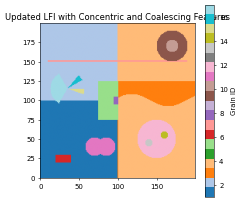

In [2]:
lfi = gridOps.generate_test_2D_LFI_1(plotlfi=True, figsize=(5, 5), dpi=50)

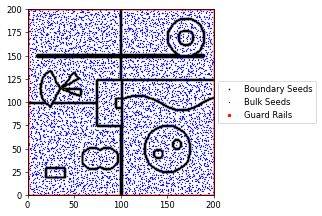

In [3]:
seeds = gridOps.generate_constrained_hybrid_seeds(lfi, target_spacing=0.5, bulk_spacing=5.0,
                             jitter_factor=1.0, margin=0.0, padding=1.0, plot_seeds=True,
                             figsize=(5, 5), dpi=60, markersize=1)

In [4]:
manifold_structure = GrainManifold2D.by_tessellation(lfi, seeds)

In [5]:
original_cells = {gid: geom for gid, geom in manifold_structure.cells.items()}

In [6]:
manifold_structure.smooth_interfaces(iterations=10, lmbda=0.5, mu=-0.53)

In [7]:
cells = manifold_structure.trim_to_rve(bounds=(6, 6, 194, 194))

(<Figure size 1200x600 with 3 Axes>,
 array([<Axes: title={'center': 'Subplot 1'}>,
        <Axes: title={'center': 'Subplot 2'}>,
        <Axes: title={'center': 'Subplot 3'}>], dtype=object))

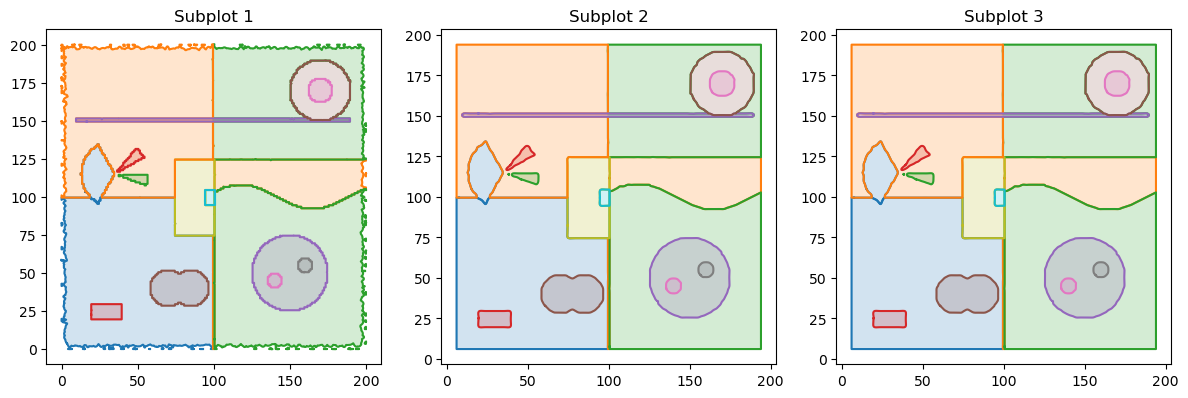

In [8]:
gsviz.plot_manifold_geom([original_cells, manifold_structure.cells, cells], figsize=(12, 6), dpi=100, inlude_legend=False)

In [9]:
xbound, ybound = [0, 300], [0, 300]
xpad, ypad = 30, 30

xbound, ybound = [xbound[0] - xpad, xbound[1] + xpad], [ybound[0] - ypad, ybound[1] + ypad]

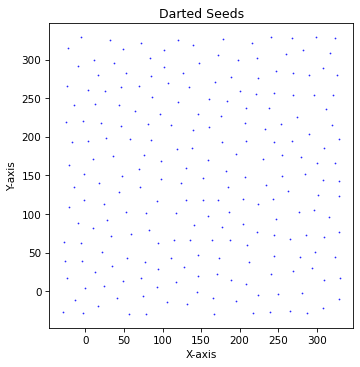

In [10]:
vorSeeds = gridOps.generate_darted_seeds(xbound, ybound, radius=20, k=100, see_seeds=True, figsize=(5, 5), dpi=75, point_size=2, plot_legend=False)

In [11]:
import numpy as np
from scipy.spatial import Voronoi
from shapely.geometry import Polygon, box
from shapely.ops import unary_union

def generate_clamped_voronoi(vorSeeds, xbound=[0, 300], ybound=[0, 300]):
    """
    Generates a Voronoi tessellation where every cell is forced 
    to be a closed polygon within the specified rectangular RVE.
    """
    from scipy.spatial import Voronoi
    from shapely.geometry import Polygon, box
    import numpy as np

    # 1. Define the RVE boundary box
    rve_box = box(xbound[0], ybound[0], xbound[1], ybound[1])
    
    # 2. Compute Voronoi regions
    vor = Voronoi(vorSeeds)
    clamped_polygons = []

    for point_idx, region_idx in enumerate(vor.point_region):
        region = vor.regions[region_idx]
        
        # Infinite regions contain -1; we must close them by 
        # intersecting with a sufficiently large bounding box
        if not region or -1 in region:
            # Note: For v6/v7 logic, use Guard Rails to avoid 
            # manually handling infinite vertices
            continue

        # Convert to Shapely Polygon
        vertices = vor.vertices[region]
        poly = Polygon(vertices)
        
        # 3. The 'Cookie Cutter' Step
        # This recovers the missing space at the RVE edges
        if poly.intersects(rve_box):
            clamped_poly = poly.intersection(rve_box)
            if not clamped_poly.is_empty:
                clamped_polygons.append(clamped_poly)
                
    return clamped_polygons

In [12]:
cells = generate_clamped_voronoi(vorSeeds, xbound=[0, 300], ybound=[0, 300])

In [13]:
cells = {i: cells[i] for i in range(len(cells))}

(<Figure size 1200x600 with 1 Axes>, [<Axes: title={'center': 'Subplot 1'}>])

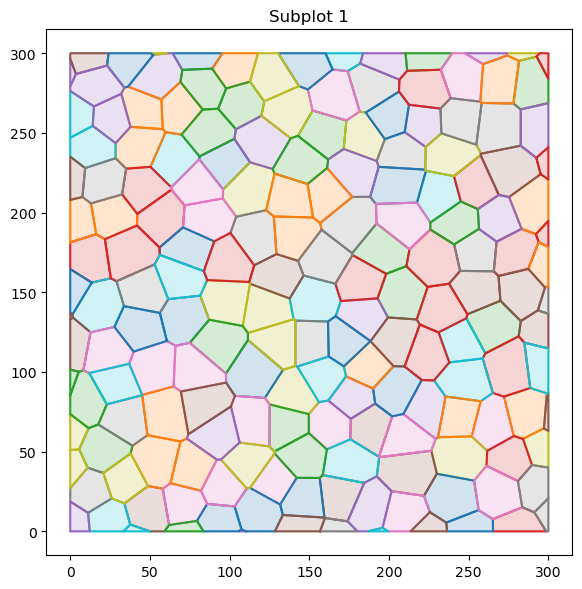

In [14]:
gsviz.plot_manifold_geom([cells], figsize=(12, 6), dpi=100, inlude_legend=False)